<a href="https://colab.research.google.com/github/surviva21/F1_performance_analysis/blob/main/F1_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Focus: 2023 Singapore Grand Prix
Investigating the tyre strategy and race pace of Carlos Sainz in the 2023 Singapore GP.

Data Source: OpenF1 API

In [1]:
#importing the libraries
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [2]:
#getting session data
session_url = (
    "https://api.openf1.org/v1/sessions"
    "?year=2023"
    "&country_name=Singapore"
    "&session_name=Race"
)
response = requests.get(session_url)
session_data = response.json()
session_data

[{'session_key': 9165,
  'session_type': 'Race',
  'session_name': 'Race',
  'date_start': '2023-09-17T12:00:00+00:00',
  'date_end': '2023-09-17T14:00:00+00:00',
  'meeting_key': 1219,
  'circuit_key': 61,
  'circuit_short_name': 'Singapore',
  'country_key': 157,
  'country_code': 'SGP',
  'country_name': 'Singapore',
  'location': 'Marina Bay',
  'gmt_offset': '08:00:00',
  'year': 2023,
  'is_cancelled': False}]

In [3]:
#saving session key as a variable
session_key = session_data[0]["session_key"]
print("Session key:", session_key)

Session key: 9165


In [4]:
#getting the lap data
laps_url = f"https://api.openf1.org/v1/laps?session_key={session_key}"
response = requests.get(laps_url)
laps_data = response.json()
laps = pd.DataFrame(laps_data)
laps.head(10)

,meeting_key,session_key,driver_number,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed
0,1219,9165,24,1,None,NaN,45.252,28.998,283.0,238.0,False,NaN,"[None, 2064, 2064, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2051, 2049, 2049, 2049]",NaN
1,1219,9165,55,1,2023-09-17T12:03:44.658000+00:00,31.630,43.449,28.577,286.0,254.0,False,103.656,"[None, 2049, 2049, 2051, 2051, 2051, 2049, 2049]","[2051, 2049, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2051, 2049, 2049, 2051, 2051]",187.0
2,1219,9165,63,1,2023-09-17T12:03:44.658000+00:00,33.857,43.702,28.566,291.0,264.0,False,106.125,"[None, 2049, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2051, 2049, 2051]","[2049, 2049, 2049, 2049, 2051, 2049, 2049, 2049]",190.0
3,1219,9165,44,1,2023-09-17T12:03:44.658000+00:00,33.855,42.982,28.538,284.0,254.0,False,105.375,"[2048, 2049, 2051, 2049, 2049, 2049, 2049, 2049]","[2049, 2051, 2049, 2051, 2051, 2049, 2049, 2049]","[2051, 2049, 2049, 2049, 2049, 2049, 2049, 2049]",204.0
4,1219,9165,16,1,2023-09-17T12:03:44.658000+00:00,32.502,43.537,28.867,271.0,257.0,False,104.906,"[None, 2049, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2051, 2049, 2049, 2049, 2051, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2051, 2051]",200.0
5,1219,9165,4,1,2023-09-17T12:03:44.658000+00:00,33.993,44.349,28.439,280.0,264.0,False,106.781,"[None, 2049, 2049, 2049, 2049, 2049, 2051, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2051, 2049, 2049, 2049, 2049, 2048]",201.0
6,1219,9165,14,1,2023-09-17T12:03:44.658000+00:00,34.444,44.826,28.449,298.0,262.0,False,107.719,"[2048, 2049, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2051, 2048]",211.0
7,1219,9165,20,1,2023-09-17T12:03:44.658000+00:00,34.850,45.219,28.650,302.0,258.0,False,108.719,"[None, 2049, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2051, 2049, 2051]",210.0
8,1219,9165,31,1,2023-09-17T12:03:44.658000+00:00,34.554,45.011,28.591,292.0,262.0,False,108.156,"[None, 2049, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2051, 2049, 2049, 2049, 2049, 2049, 2049]",215.0
9,1219,9165,27,1,2023-09-17T12:03:44.658000+00:00,35.215,45.507,28.825,288.0,258.0,False,109.547,"[None, 2049, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 2048]",220.0


In [5]:
#getting driver names for the graphs
drivers_url = f"https://api.openf1.org/v1/drivers?session_key={session_key}"
response = requests.get(drivers_url)
drivers_data = response.json()
drivers = pd.DataFrame(drivers_data)
drivers.head()

,meeting_key,session_key,driver_number,broadcast_name,full_name,name_acronym,team_name,team_colour,first_name,last_name,headshot_url,country_code
0,1219,9165,1,M VERSTAPPEN,Max VERSTAPPEN,VER,Red Bull Racing,3671C6,Max,Verstappen,https://www.formula1.com/content/dam/fom-websi...,NED
1,1219,9165,2,L SARGEANT,Logan SARGEANT,SAR,Williams,37BEDD,Logan,Sargeant,https://www.formula1.com/content/dam/fom-websi...,USA
2,1219,9165,4,L NORRIS,Lando NORRIS,NOR,McLaren,F58020,Lando,Norris,https://www.formula1.com/content/dam/fom-websi...,GBR
3,1219,9165,10,P GASLY,Pierre GASLY,GAS,Alpine,2293D1,Pierre,Gasly,https://www.formula1.com/content/dam/fom-websi...,FRA
4,1219,9165,11,S PEREZ,Sergio PEREZ,PER,Red Bull Racing,3671C6,Sergio,Perez,https://www.formula1.com/content/dam/fom-websi...,MEX


In [6]:
#merging driver names and lap data
clean_laps = laps[
    [
        "driver_number",
        "lap_number",
        "lap_duration",
        "duration_sector_1",
        "duration_sector_2",
        "duration_sector_3",
        "i1_speed",
        "i2_speed",
        "st_speed",
        "is_pit_out_lap"
    ]
].copy()
clean_laps = clean_laps.merge(
    drivers[
        [
            "driver_number",
            "name_acronym",
            "full_name",
            "team_name"
        ]
    ],
    on="driver_number",
    how="left"
)
clean_laps.head(20)


,driver_number,lap_number,lap_duration,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,st_speed,is_pit_out_lap,name_acronym,full_name,team_name
0,24,1,NaN,NaN,45.252,28.998,283.0,238.0,NaN,False,ZHO,ZHOU Guanyu,Alfa Romeo
1,55,1,103.656,31.630,43.449,28.577,286.0,254.0,187.0,False,SAI,Carlos SAINZ,Ferrari
2,63,1,106.125,33.857,43.702,28.566,291.0,264.0,190.0,False,RUS,George RUSSELL,Mercedes
3,44,1,105.375,33.855,42.982,28.538,284.0,254.0,204.0,False,HAM,Lewis HAMILTON,Mercedes
4,16,1,104.906,32.502,43.537,28.867,271.0,257.0,200.0,False,LEC,Charles LECLERC,Ferrari
5,4,1,106.781,33.993,44.349,28.439,280.0,264.0,201.0,False,NOR,Lando NORRIS,McLaren
6,14,1,107.719,34.444,44.826,28.449,298.0,262.0,211.0,False,ALO,Fernando ALONSO,Aston Martin
7,20,1,108.719,34.850,45.219,28.650,302.0,258.0,210.0,False,MAG,Kevin MAGNUSSEN,Haas F1 Team
8,31,1,108.156,34.554,45.011,28.591,292.0,262.0,215.0,False,OCO,Esteban OCON,Alpine
9,27,1,109.547,35.215,45.507,28.825,288.0,258.0,220.0,False,HUL,Nico HULKENBERG,Haas F1 Team


In [7]:
#removing the rows that dont have lap times and ensuring carlos is still there
clean_laps = clean_laps.dropna(subset=["lap_duration"])
print("Number of laps:", len(clean_laps))
print("Number of drivers:", clean_laps["driver_number"].nunique())
clean_laps[clean_laps["driver_number"] == 55].head()

Number of laps: 1083
Number of drivers: 18


,driver_number,lap_number,lap_duration,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,st_speed,is_pit_out_lap,name_acronym,full_name,team_name
1,55,1,103.656,31.630,43.449,28.577,286.0,254.0,187.0,False,SAI,Carlos SAINZ,Ferrari
19,55,2,101.383,29.636,43.260,28.487,280.0,253.0,275.0,False,SAI,Carlos SAINZ,Ferrari
37,55,3,100.962,29.601,42.876,28.485,273.0,254.0,276.0,False,SAI,Carlos SAINZ,Ferrari
55,55,4,100.580,29.390,42.937,28.253,280.0,256.0,277.0,False,SAI,Carlos SAINZ,Ferrari
73,55,5,100.551,29.513,42.812,28.226,279.0,257.0,278.0,False,SAI,Carlos SAINZ,Ferrari


There is 18 drivers as Yuki Tsunoda DNF on Lap 1 and Lance Stroll DNS

In [8]:
#Tyre Stint Data
stints_url = f"https://api.openf1.org/v1/stints?session_key={session_key}"
response = requests.get(stints_url)
stints_data = response.json()
stints = pd.DataFrame(stints_data)
stints.head(10)


,meeting_key,session_key,stint_number,driver_number,lap_start,lap_end,compound,tyre_age_at_start
0,1219,9165,1,10,1.0,20.0,MEDIUM,0
1,1219,9165,1,81,1.0,20.0,MEDIUM,0
2,1219,9165,1,16,1.0,20.0,SOFT,3
3,1219,9165,1,11,1.0,39.0,HARD,0
4,1219,9165,1,22,NaN,NaN,SOFT,0
5,1219,9165,1,31,1.0,20.0,MEDIUM,0
6,1219,9165,1,77,1.0,40.0,HARD,0
7,1219,9165,1,63,1.0,20.0,MEDIUM,0
8,1219,9165,1,27,1.0,20.0,MEDIUM,0
9,1219,9165,1,2,1.0,19.0,MEDIUM,0


In [9]:
#displaying only Carlos's stints
sainz_stints = stints[stints["driver_number"] == 55].copy()
sainz_stints

,meeting_key,session_key,stint_number,driver_number,lap_start,lap_end,compound,tyre_age_at_start
12,1219,9165,1,55,1.0,20.0,MEDIUM,0
20,1219,9165,2,55,21.0,62.0,HARD,0


Carlos had a 2 tyre stints.
He was on Mediums for the first 20 laps and then he switched to Hards for the remaining laps.

In [10]:
# Displaying only Carlos's laps
sainz_laps = clean_laps[clean_laps["driver_number"] == 55].copy()
sainz_laps.head()

,driver_number,lap_number,lap_duration,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,st_speed,is_pit_out_lap,name_acronym,full_name,team_name
1,55,1,103.656,31.630,43.449,28.577,286.0,254.0,187.0,False,SAI,Carlos SAINZ,Ferrari
19,55,2,101.383,29.636,43.260,28.487,280.0,253.0,275.0,False,SAI,Carlos SAINZ,Ferrari
37,55,3,100.962,29.601,42.876,28.485,273.0,254.0,276.0,False,SAI,Carlos SAINZ,Ferrari
55,55,4,100.580,29.390,42.937,28.253,280.0,256.0,277.0,False,SAI,Carlos SAINZ,Ferrari
73,55,5,100.551,29.513,42.812,28.226,279.0,257.0,278.0,False,SAI,Carlos SAINZ,Ferrari


In [11]:
# Creating a new column for the tyre compound
sainz_laps["compound"] = None
# Matching each lap to the tyre stint.
#This is so we know if the type affected the timing
for index, stint in sainz_stints.iterrows():
    sainz_laps.loc[
        (sainz_laps["lap_number"] >= stint["lap_start"]) &
        (sainz_laps["lap_number"] <= stint["lap_end"]),
        "compound"
    ] = stint["compound"]

In [12]:
# Reload pit-stop data for Singapore 2023
pit_url = f"https://api.openf1.org/v1/pit?session_key={session_key}"
response = requests.get(pit_url)
pit_data = response.json()
pit_stops = pd.DataFrame(pit_data)
#displaying pit stop data
sainz_pits = pit_stops[pit_stops["driver_number"] == 55].copy()
sainz_pits

,date,session_key,pit_duration,lap_number,lane_duration,meeting_key,driver_number,stop_duration
2,2023-09-17T12:37:49.400000+00:00,9165,29.4,20,29.4,1219,55,None


In [13]:
# Get race control messages for Singapore 2023

race_control_url = (
    f"https://api.openf1.org/v1/race_control"
    f"?session_key={session_key}"
)
response = requests.get(race_control_url)
race_control_data = response.json()
race_control = pd.DataFrame(race_control_data)

lap 20 -> pit stop and safety car
lap 21 -> pit stop lap and safety car
lap 22 -> lap time affected by being behind safety car
lap 23 -> getting back to speed
lap 24 -> normal racing pace

Safety car due Logan' debris.

In [14]:
# excluding laps affected by pit stop and safety car
excluded_laps = [20, 21, 22, 43, 44, 45]
sainz_pace_laps = sainz_laps[
    ~sainz_laps["lap_number"].isin(excluded_laps)
].copy()
print("All completed Sainz laps:", len(sainz_laps))
print("Race pace laps:", len(sainz_pace_laps))

All completed Sainz laps: 62
Race pace laps: 56


In [15]:
# Displaying the tyre age for each of the laps
sainz_laps["tyre_age"] = None
for index, stint in sainz_stints.iterrows():
    mask = (
        (sainz_laps["lap_number"] >= stint["lap_start"]) &
        (sainz_laps["lap_number"] <= stint["lap_end"])
    )
    sainz_laps.loc[mask, "tyre_age"] = (
        sainz_laps.loc[mask, "lap_number"]
        - stint["lap_start"]
        + stint["tyre_age_at_start"]
    )


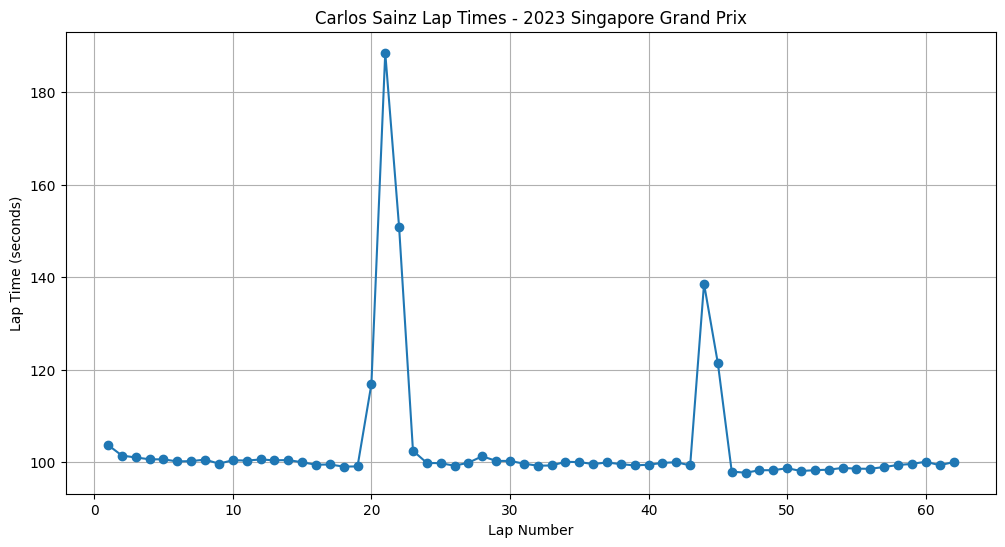

In [16]:
#carlos sainz lap pace across the race
plt.figure(figsize=(12, 6))
plt.plot(
    sainz_laps["lap_number"],
    sainz_laps["lap_duration"],
    marker="o"
)
plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.title("Carlos Sainz Lap Times - 2023 Singapore Grand Prix")
plt.grid(True)
plt.show()

## Interpretation:

Carlos's lap times remain relatively consistent for most of the race, but there are several large spikes around laps 20–22 and 43–45. These slower laps are associated with pit-stop and race-control periods rather than normal race pace. The first major disruption occurred around Carlos's pit stop during the Safety Car period, while the later disruption occurred around the Virtual Safety Car period.
Because these laps do not represent normal racing conditions, they are excluded from the race-pace analysis.

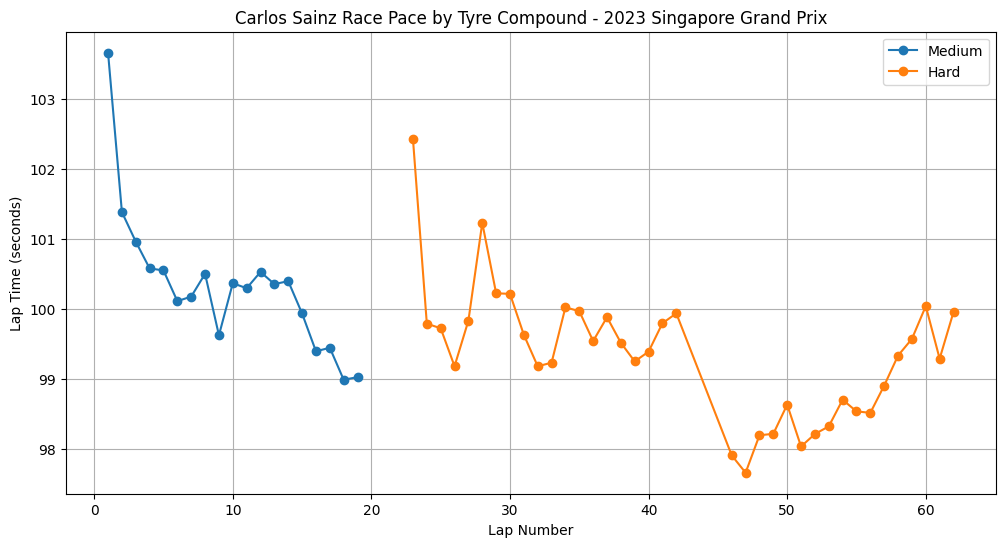

In [17]:
# Recreate the race-pace dataset so it also includes tyre age
sainz_pace_laps = sainz_laps[
    ~sainz_laps["lap_number"].isin(excluded_laps)
].copy()
#splitting it by tyre
medium_laps = sainz_pace_laps[
    sainz_pace_laps["compound"] == "MEDIUM"
]
hard_laps = sainz_pace_laps[
    sainz_pace_laps["compound"] == "HARD"
]
#plotting that graph
plt.figure(figsize=(12, 6))
plt.plot(
    medium_laps["lap_number"],
    medium_laps["lap_duration"],
    marker="o",
    label="Medium"
)
plt.plot(
    hard_laps["lap_number"],
    hard_laps["lap_duration"],
    marker="o",
    label="Hard"
)
plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.title("Carlos Sainz Race Pace by Tyre Compound - 2023 Singapore Grand Prix")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation:

Carlos finished his first stint on Medium tyres before switching to Hard tyres on lap 20. After the laps affected by the Safety Car and Virtual Safety Car were removed, the Hard stint generally produced lower lap times than the Medium stint.

However, this does not necessarily mean that the Hard tyre was inherently faster. The Medium stint occurred earlier in the race when the car carried more fuel, while the Hard stint took place later with a lighter fuel load. Traffic, track conditions and race management may also have affected the lap times.

The graph therefore shows how Carlos's race pace changed across his two tyre stints rather than providing a direct comparison of tyre performance.

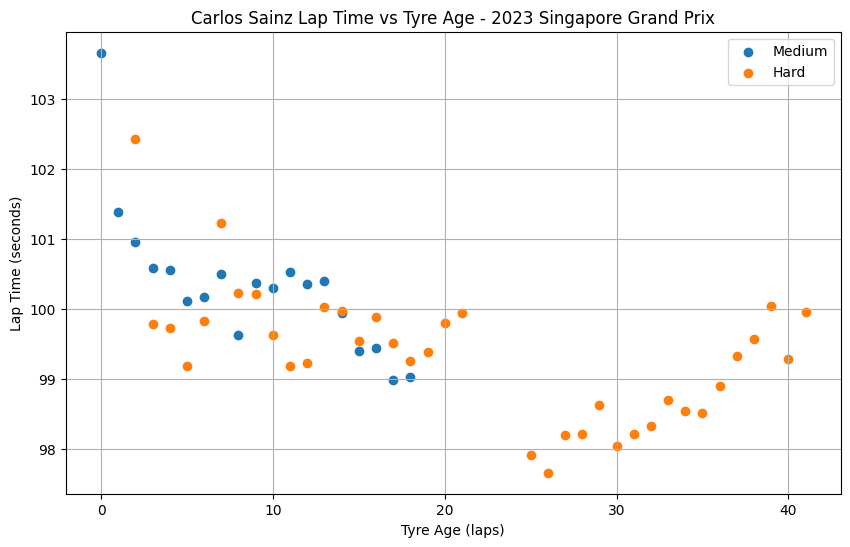

In [18]:
#plotting lap time against tyre age
plt.figure(figsize=(10, 6))
plt.scatter(
    medium_laps["tyre_age"],
    medium_laps["lap_duration"],
    label="Medium"
)
plt.scatter(
    hard_laps["tyre_age"],
    hard_laps["lap_duration"],
    label="Hard"
)
plt.xlabel("Tyre Age (laps)")
plt.ylabel("Lap Time (seconds)")
plt.title("Carlos Sainz Lap Time vs Tyre Age - 2023 Singapore Grand Prix")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation:

The relationship between tyre age and lap time does not show a simple increase in lap time as the tyres become older. During the Medium stint, lap times generally decrease even as tyre age increases. This is likely influenced by factors such as decreasing fuel load and changing track conditions.

The Hard stint shows a different pattern, with lap times improving during the earlier part of the stint before increasing again towards the end of the race.

This demonstrates that tyre degradation cannot be analysed from lap time alone. Fuel load, traffic, race conditions and pace management also influence lap performance.

In [19]:
# Summary of Sainz's race pace by tyre compounds
pace_summary = sainz_pace_laps.groupby("compound")["lap_duration"].agg(
    ["count", "mean", "median", "min", "max"]
)
pace_summary

,count,mean,median,min,max
compound,,,,,
HARD,37,99.354405,99.393,97.666,102.423
MEDIUM,19,100.331895,100.356,98.992,103.656


In [20]:
# Show the leading drivers involved in the last part of the race battle
comparison_drivers = ["SAI", "NOR", "RUS", "HAM"]

late_race = clean_laps[
    (clean_laps["name_acronym"].isin(comparison_drivers)) &
    (clean_laps["lap_number"] >= 46)
].copy()

In [21]:
# Comparing the tyre stints of Lando, George, Carlos and Lewis
comparison_numbers = [55, 4, 63, 44]
comparison_stints = stints[
    stints["driver_number"].isin(comparison_numbers)
].copy()
comparison_stints

,meeting_key,session_key,stint_number,driver_number,lap_start,lap_end,compound,tyre_age_at_start
7,1219,9165,1,63,1.0,20.0,MEDIUM,0
11,1219,9165,1,4,1.0,20.0,MEDIUM,0
12,1219,9165,1,55,1.0,20.0,MEDIUM,0
13,1219,9165,1,44,1.0,20.0,MEDIUM,0
20,1219,9165,2,55,21.0,62.0,HARD,0
22,1219,9165,2,63,21.0,44.0,HARD,0
24,1219,9165,2,4,21.0,62.0,HARD,0
25,1219,9165,2,44,21.0,44.0,HARD,0
41,1219,9165,3,63,45.0,61.0,MEDIUM,0
42,1219,9165,3,44,45.0,62.0,MEDIUM,0


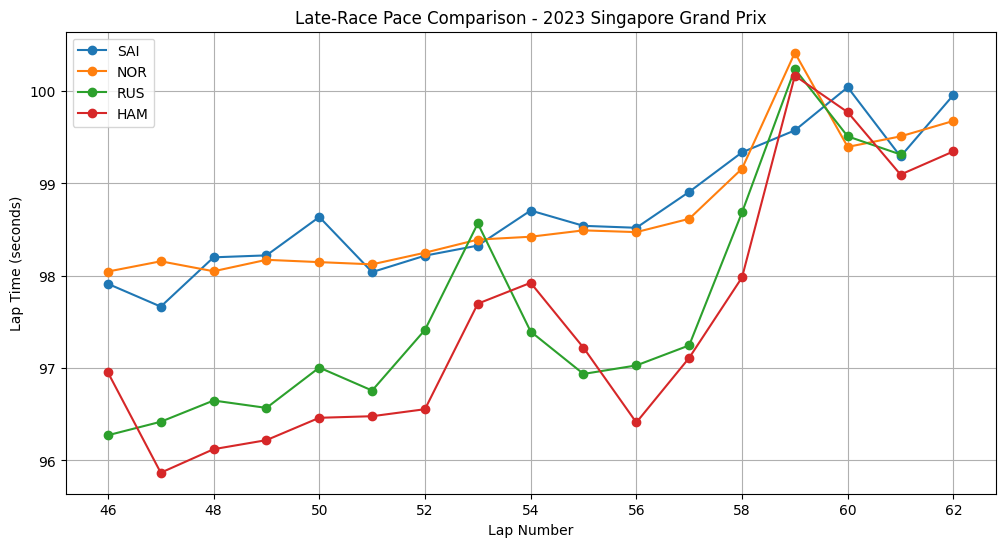

In [22]:
#plotting the graphs of the 4 driver closing stints
plt.figure(figsize=(12, 6))
for driver in comparison_drivers:
    driver_data = late_race[
        late_race["name_acronym"] == driver
    ]
    plt.plot(
        driver_data["lap_number"],
        driver_data["lap_duration"],
        marker="o",
        label=driver
    )
plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.title("Late-Race Pace Comparison - 2023 Singapore Grand Prix")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation:

From laps 46–58, George Russell and Lewis Hamilton were generally faster than Carlos Sainz and Lando Norris. George and Lewis had changed to fresh Medium tyres during the Virtual Safety Car period, while Carlos and Lando remained on older Hard tyres.

This gave Mercedes a significant late-race pace advantage and allowed George and Lewis to close the gap to the leading cars. Therfore, Carlos had to defend the race lead despite not having the strongest outright pace during the closing stages.

The higher lap times seen around lap 59 were influenced by changing race conditions and should not be interpreted purely as tyre degradation. George's data also ends before lap 62 because he crashed on the final lap.

In [23]:
# Getting the interval time data
intervals_url = f"https://api.openf1.org/v1/intervals?session_key={session_key}"
response = requests.get(intervals_url)
intervals_data = response.json()
intervals = pd.DataFrame(intervals_data)
intervals.head(10)

,date,session_key,interval,driver_number,meeting_key,gap_to_leader
0,2023-09-17T11:01:02.356000+00:00,9165,0.000,55,1219,0.000
1,2023-09-17T12:03:49.814000+00:00,9165,NaN,16,1219,0.262
2,2023-09-17T12:03:49.814000+00:00,9165,0.285,63,1219,0.285
3,2023-09-17T12:03:50.095000+00:00,9165,0.298,4,1219,0.560
4,2023-09-17T12:03:50.267000+00:00,9165,0.114,44,1219,0.674
5,2023-09-17T12:03:50.408000+00:00,9165,0.190,20,1219,0.864
6,2023-09-17T12:03:50.502000+00:00,9165,0.075,14,1219,0.939
7,2023-09-17T12:03:50.752000+00:00,9165,0.245,31,1219,1.184
8,2023-09-17T12:03:50.892000+00:00,9165,0.127,27,1219,1.311
9,2023-09-17T12:03:51.095000+00:00,9165,NaN,1,1219,1.482


In [24]:
# Convert interval timestamps to datetime
# Some timestamps include microseconds and some do not
intervals["date"] = pd.to_datetime(
    intervals["date"],
    format="mixed",
    utc=True
)

In [25]:
# Get the start time of lap 46
lap_46 = laps[
    (laps["driver_number"] == 55) &
    (laps["lap_number"] == 46)
]

lap_46_start = pd.to_datetime(
    lap_46["date_start"].iloc[0],
    utc=True
)

# Get Lando's interval data from lap 46 onwards
norris_intervals = intervals[
    (intervals["driver_number"] == 4) &
    (intervals["date"] >= lap_46_start)
].copy()

In [26]:
# Find the moment when Lando was within 1 second of Carlos
norris_close_gap = norris_intervals[
    norris_intervals["interval"] <= 1.0
].copy()

In [27]:

print("Number of readings within 1 second:", len(norris_close_gap))
print("Smallest gap:", norris_intervals["interval"].min())

Number of readings within 1 second: 109
Smallest gap: 0.328


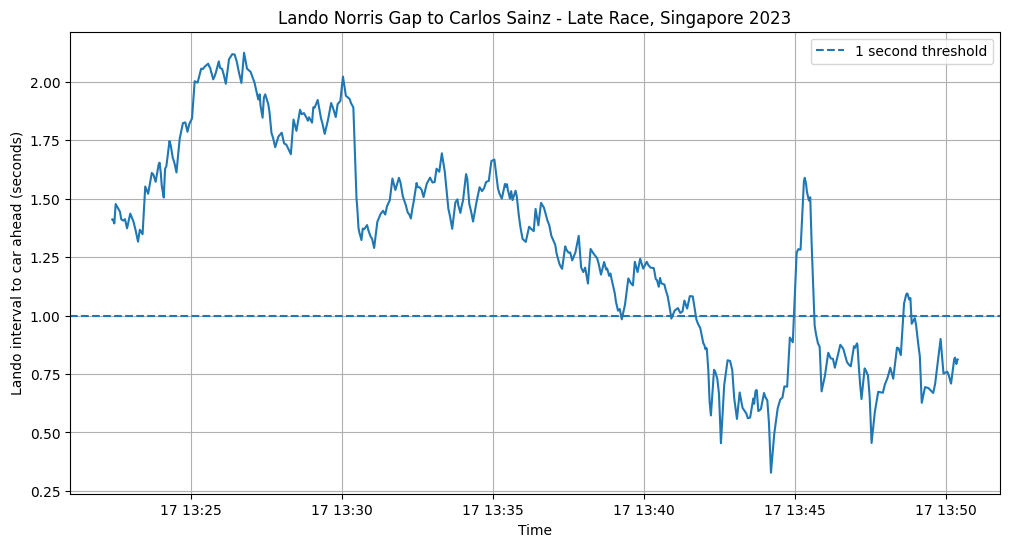

In [28]:
#plotting the gap between Lando and Carlos from lap 46
plt.figure(figsize=(12, 6))
plt.plot(
    norris_intervals["date"],
    norris_intervals["interval"]
)
plt.axhline(
    y=1.0,
    linestyle="--",
    label="1 second threshold"
)
plt.xlabel("Time")
plt.ylabel("Lando interval to car ahead (seconds)")
plt.title("Lando Norris Gap to Carlos Sainz - Late Race, Singapore 2023")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation:

At the beginning of the late-race period, Lando was generally more than one second behind Carlos, with the gap reaching approximately two seconds at some points.

As the race progressed, the gap gradually decreased. During the closing stages, Lando frequently ran within approximately one second of Carlos. In the interval dataset, 109 readings were recorded at or below one second, with the smallest recorded gap being 0.328 seconds.

This pattern is consistent with Carlos closely managing the gap to Norris during the final stages of the race. Keeping Lando close also placed him between Carlos and the faster Mercedes drivers, which became an important part of the battle for the lead.

The interval data is not recorded specifically at each official DRS detection point, so it cannot independently prove that Lando received DRS at every moment shown below one second. However, it provides strong evidence of how closely Carlos managed the gap during the closing stages.